In [40]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
from scipy import stats
from nilearn import datasets
from collections import Counter
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET  
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms

In [41]:
with open("schaefer_parcel_counts.pkl", 'rb') as f:
    parcel_voxel_counts = pickle.load(f)
    
with open('/home/zachkaras/fmri_model/analysis/fir/schaefer_parcel_labels.pkl', 'rb') as f:
    schaefer_parcel_labels = pickle.load(f)

with open("/tank/home/zachkaras/fmri_model/analysis/fir/Harvard_Oxford_voxel_counts.pkl", 'rb') as f:
    harvOx_voxel_counts = pickle.load(f)
        
with open("/tank/home/zachkaras/fmri_model_data/intermediate_results/all_results_regressor+features.pkl", 'rb') as f:
    records = pickle.load(f)
    
with open("/tank/home/zachkaras/fmri_model_data/intermediate_results/participant_means.pkl", 'rb') as f:
    participant_means = pickle.load(f)
    
    
    
# inpath = '/data/zachkaras/fmri_model_data/intermediate_results' 
# with open(f"{inpath}/enrichment_analysis_results.pkl", 'rb') as f:
#     enriched_parcels = pickle.load(f)

random.seed(111)

model_labels = {
    'deepseek_6b' : 'DeepSeek 6B',
}

task_labels = {
    'code' : 'Code',
    'prose': 'Prose'
}

demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")
participants = os.listdir("midprocess")
participants.remove('101')
participants.remove('130')
# participants = sorted([pid for pid in list(jaccards['code'].keys()) if pid in list(jaccards['prose'].keys())])


In [42]:
temp = records['top_regions'].apply(lambda row: len(row))
print(10000 - np.mean(temp))

715.2146701388883


In [50]:
important_participants = ['117', '125', '108']


# def translate_to_region_names(top_voxel_idx):
#     # using top voxel idx, find the corresponding Harvard Oxford region number
#     # translate voxel number to region name

#     atlas_base_path = "/home/zachkaras/fmri_model/analysis/pipeline/atlases"


#     # Loading in atlas and labels for harvard-oxford atlas regions
#     ho_data = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
#     atlas = nib.load(ho_data['filename']).get_fdata()

#     ho_labels = "/home/zachkaras/atlases/HarvardOxford-Cortical.xml"
#     labels = [label.text for label in ET.parse(ho_labels).getroot().iter('label')] # indices are the region numbers - need to add one though

#     # read in 2d mni mask
#     mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
#     mask = mask.get_fdata().flatten()
#     brain_idx = np.where(mask>0)[0]

#     # atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
#     atlas_vec = atlas.get_fdata().flatten()
#     atlas_only_brain = atlas_vec[brain_idx] # contains the Harvard-Oxford numbers
#     cortex_vx = np.where(atlas_only_brain != 0)[0]
#     ho_nums = atlas_only_brain[cortex_vx]


"""
def translate_to_region_names(parcel_num, schaefer_labels):
        parcel_num = int(parcel_num)
        if parcel_num <= 200:
            region = f"Left {schaefer_labels['left'][parcel_num]}"
        else:
            region = f"Right {schaefer_labels['right'][parcel_num]}"
        return region
"""

def get_top_five_regions(parcel_dict):
    parcel_dict = dict(sorted(parcel_dict.items(), key= lambda x: x[1], reverse=True))
    return {region : val for i,(region,val) in enumerate(parcel_dict.items()) if i < 5}

def convert_HarvOx_counts_to_proportions(count_dict):
    new_dict = {}
    for region,count in count_dict.items():
        proportion = count / harvOx_voxel_counts[region]
        new_dict[region] = proportion
    return new_dict

def plot_participant_parcels_across_layers(p, model, task, parcel_dict, region_colors, jaccard):
    # Build rows, sorting each layer's regions by score descending
    rows = []
    for _, row in parcel_dict.iterrows():
        layer = str(row['layer'])
        sorted_regions = sorted(row['top_five_regions'].items(), key=lambda x: x[1], reverse=True)[:5]
        for rank, (region, val) in enumerate(sorted_regions):
            rows.append({'layer': layer, 'region': region, 'score': val, 'rank': rank})
    df = pd.DataFrame(rows)
    # print(df)

    layers = sorted(df['layer'].unique(), key=lambda x: int(x.split('_')[1]))
    layer_labels = [x.split('_')[1] for x in layers]

    n_bars = 5
    bar_width = 0.15
    gap = 0.3  # extra space between groups

    fig, ax = plt.subplots(figsize=(10, 6))
    group_centers = []

    for g_idx, layer in enumerate(layers):
        layer_df = df[df['layer'] == layer].sort_values('score', ascending=False)
        n = len(layer_df)
        offsets = np.arange(n) * bar_width - (n - 1) * bar_width / 2
        center = g_idx * (n_bars * bar_width + gap)
        group_centers.append(center)
        for b_idx, (_, r) in enumerate(layer_df.iterrows()):
            ax.bar(center + offsets[b_idx], r['score'], width=bar_width,
                   color=region_colors[r['region']], edgecolor='black',
                   label=r['region'])

    # Deduplicated legend (first occurrence of each region)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Region", loc='upper right', fontsize=12)

    ax.set_xticks(group_centers)
    # ax.set_xticklabels(layers, rotation=45, ha='right')
    ax.set_xticklabels(layer_labels, ha='right', fontsize=16)
    ax.set_xlabel("Layer", fontsize=16)
    ax.set_ylim([0, 2500])
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylabel("Voxels Among Top 10K Per Region", fontsize=16)
    ax.set_title(f"Top Regions Modeled Per Layer - Participant {p}\n{model_labels[model]}-{task_labels[task]} - Jaccard Index: {jaccard:.3f}", fontsize=22)
    plt.tight_layout()
    # plt.savefig(f"/data/zachkaras/fmri_model_data/plots/layer_regions-{p}-{task}.png", dpi=200)
    plt.savefig(f"/tank/home/zachkaras/fmri_model_data/plots/layer_regions-{p}-{task}.png", dpi=200)
    plt.show()

def compute_jaccard(df):
    list_of_sets = [set(row['top_five_regions'].keys()) for i,row in df.iterrows()]
    intersection = set.intersection(*list_of_sets)
    union = set.union(*list_of_sets)
    return len(intersection) / len(union)
        

In [44]:
all_regions_global = set()
for vip in important_participants:
    mask = ((records['participant'] == vip) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        
        df['top_region_counts'] = df['top_regions'].apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_region_counts'].apply(lambda row: get_top_five_regions(row))
        
        for top_five in df['top_five_regions']:
            all_regions_global.update(top_five.keys())

all_regions_global = sorted(all_regions_global)  # sort for deterministic ordering
palette = sns.color_palette("rainbow", len(all_regions_global))
rng = np.random.default_rng(seed=1) # 111 is pretty good
rng.shuffle(palette)
region_colors = {r: palette[i] for i, r in enumerate(all_regions_global)}

In [45]:
# all participants
jaccards = {
    'code' :{},
    'prose':{}
}
for p in participants:
    mask = ((records['participant'] == p) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        df['top_region_counts'] = df['top_regions'].apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_region_counts'].apply(lambda row: get_top_five_regions(row))
        
        filtered = df[['layer', 'top_five_regions']].copy()
        filtered = filtered.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))
        jaccard_index = compute_jaccard(filtered)
        jaccards[task][p] = jaccard_index
        # print(p, model, task, jaccard_index)

In [46]:
for task in ['code', 'prose']:
    mean = np.mean(list(jaccards[task].values()))
    std = np.std(list(jaccards[task].values()))
    print(f"{task_labels[task]} ($\\mu={mean:.3f}$, $\\sigma={std:.3f}$)")
    
t,p = stats.ttest_rel(list(jaccards['code'].values()), list(jaccards['prose'].values()))
print(f"($t={t:.3f}$, ${p:.3f}$)", p)

Code ($\mu=0.661$, $\sigma=0.263$)
Prose ($\mu=0.620$, $\sigma=0.221$)
($t=0.586$, $0.564$) 0.5637059617736326


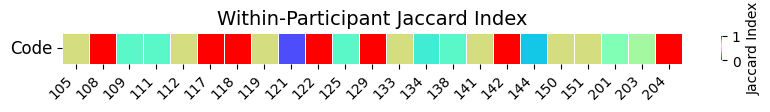

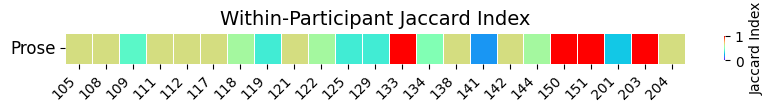

In [47]:
# participants = sorted(
#     set(jaccards['code'].keys()) & set(jaccards['prose'].keys()),
#     key=lambda p: jaccards['code'][p]
# )
participants = sorted([pid for pid in list(jaccards['code'].keys()) if pid in list(jaccards['prose'].keys())])

for task in ['code', 'prose']:
    # print(participants)
    data = [[jaccards[task][p]  for p in participants]]
    # print(data)
    # for i,d in enumerate(data[0]):
        # print(participants[i], d)
    # fig, ax = plt.subplots(figsize=(max(10, len(participants) * 0.65), 2.5))
    fig, ax = plt.subplots(figsize=(10, 0.4))
    sns.heatmap(
        data,
        # annot=True,
        fmt='.3f',
        cmap='rainbow',
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        # annot_kws={'size': 9},
        cbar_kws={'label': 'Jaccard Index', 'shrink': 0.8},
    )
    ax.set_xticks(np.arange(len(participants)) + 0.5)
    ax.set_xticklabels(participants, rotation=45, ha='right', fontsize=10)
    # ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels([task_labels[task]], rotation=0, va='center', fontsize=12)
    ax.set_title('Within-Participant Jaccard Index', fontsize=14)
    # plt.tight_layout()
    plt.savefig(f'/tank/home/zachkaras/fmri_model_data/plots/jaccard_vector_heatmap_deepseek6b_{task}.png', dpi=200)
    plt.show()

In [48]:
def calculate_correlation(task):

    performance = participant_means[task]
    jaccard = jaccards[task]

    performance = dict(sorted(performance.items()))
    
    jaccard = dict(sorted(jaccard.items()))
    
    x,y = list(performance.values()), list(jaccard.values())
    # print(len(x))
    # print(len(y))
    r,p = stats.pearsonr(x,y)
    print(f"{task_labels[task]} ($r={r:.3f}$, $p={p:.3f}$)", p)

    
calculate_correlation('code')
calculate_correlation('prose')



Code ($r=0.257$, $p=0.236$) 0.23648248857900858
Prose ($r=0.114$, $p=0.604$) 0.6042746598828523


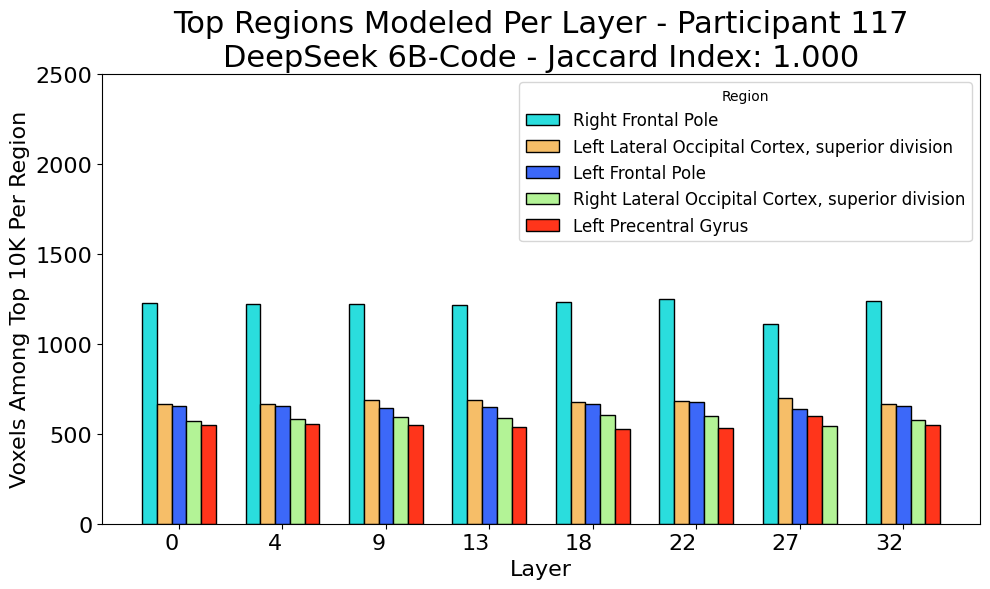

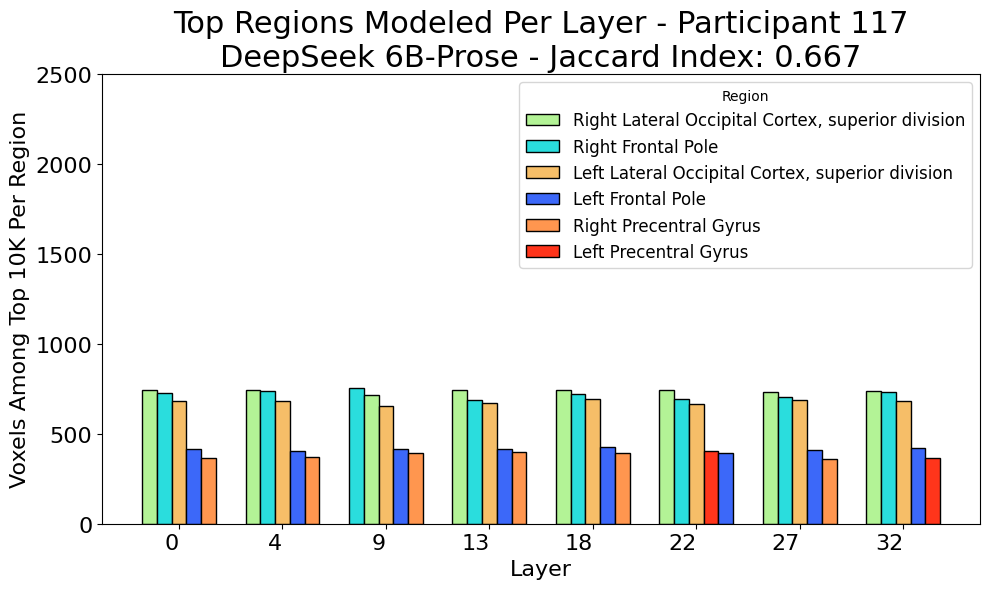

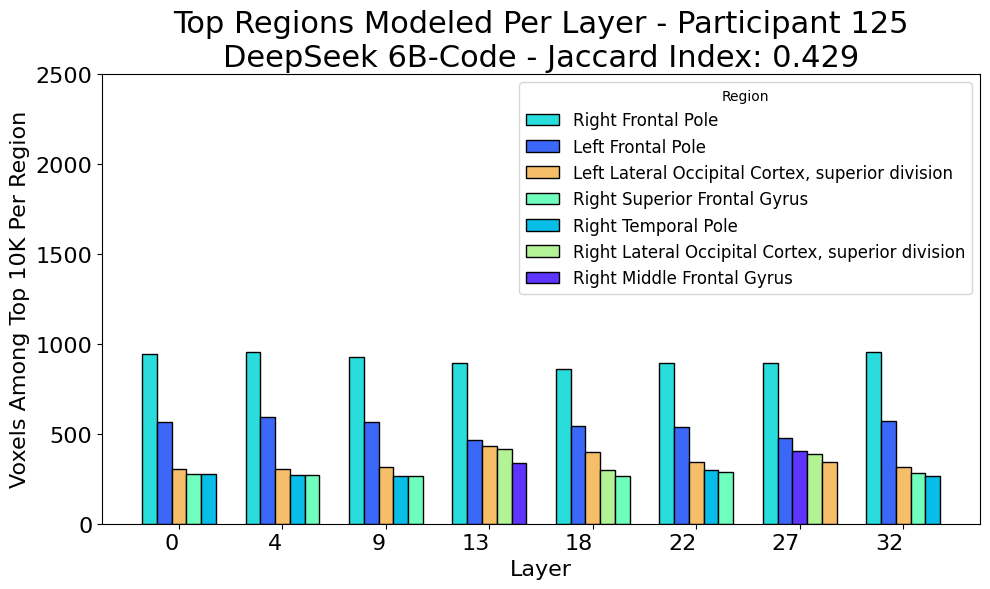

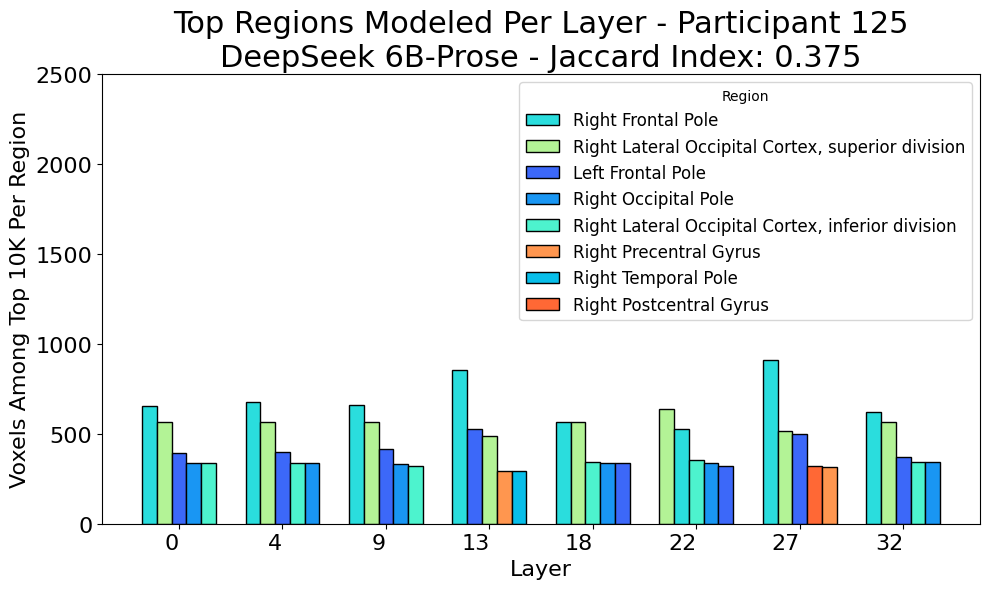

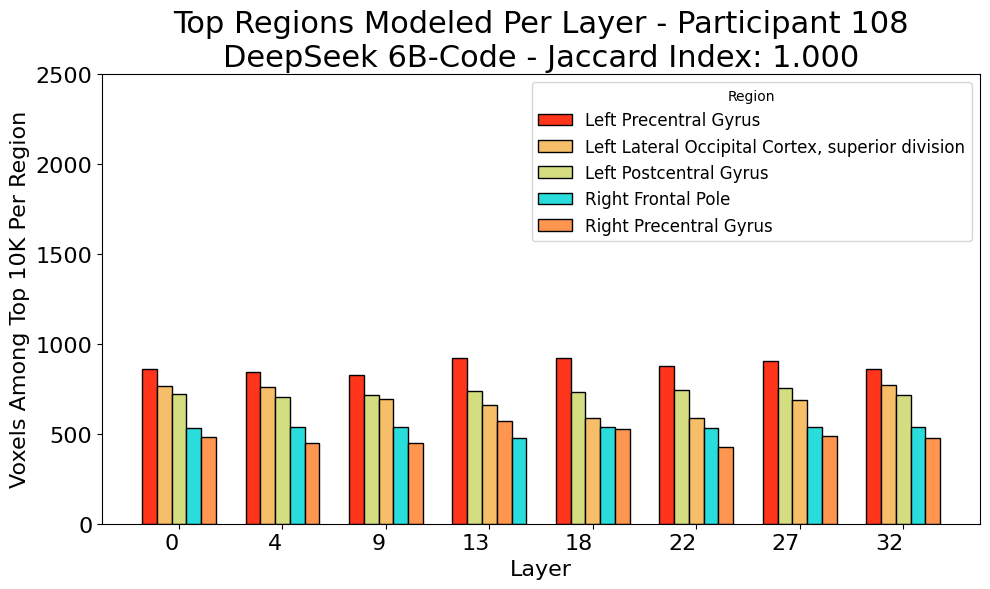

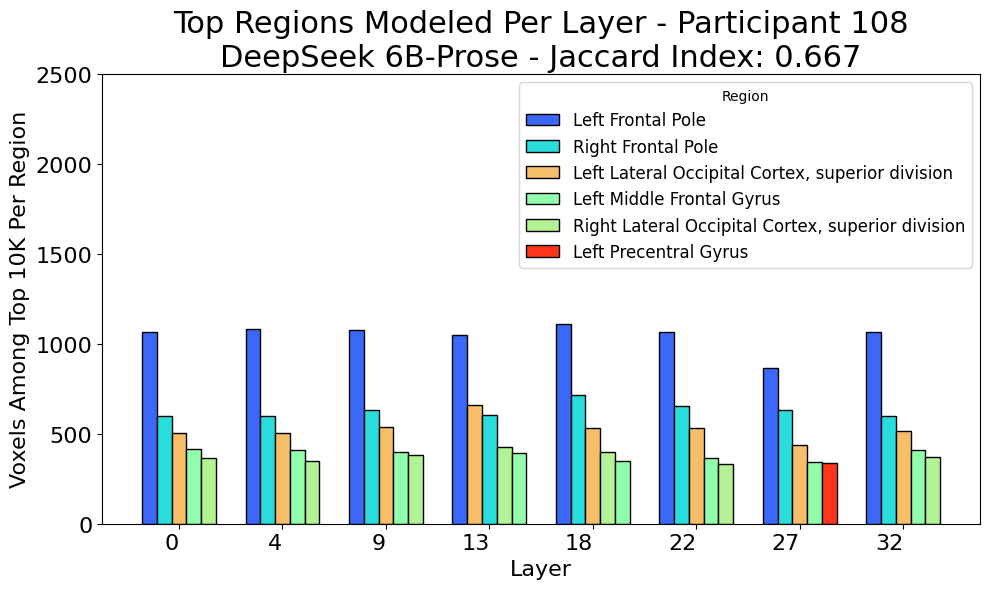

In [51]:

for vip in important_participants:
    mask = ((records['participant'] == vip) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        df['top_region_counts'] = df['top_regions'].apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_region_counts'].apply(lambda row: get_top_five_regions(row))

        filtered = df[['layer', 'top_five_regions']].copy()
        filtered = filtered.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))
        jaccard_index = compute_jaccard(filtered)

        plot_participant_parcels_across_layers(vip, model, task, filtered, region_colors, jaccard_index)


In [52]:
top_five_regions = {
    'code' : {},
    'prose': {}
}
for p in participants:
    mask = ((records['participant'] == p) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        # explode by layer
        df['top_region_counts'] = df['top_regions'].apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_region_counts'].apply(lambda row: get_top_five_regions(row))
        top_five_regions[task][p] = set(df['top_five_regions'].explode())

In [53]:
with open('typing_counts.pkl', 'rb') as f:
    typing_counts = pickle.load(f)
    

# Add keystroke-based variables to demo_data (separately for code and prose)
for pid_str, tasks in typing_counts.items():
    pid = int(pid_str)
    for task in ['code', 'prose']:
        try:
            total_keys = tasks[task]['total_keys_pressed']
        except:
            print(f"No {task} task for {pid}.")
            continue
        total_backspaces = tasks[task]['total_backspaces']
        mask = demo_data['id'] == pid
        demo_data.loc[mask, f'{task}_total_keystrokes'] = total_keys
        demo_data.loc[mask, f'{task}_editing_rate'] = total_backspaces / total_keys if total_keys > 0 else float('nan')


No prose task for 101.
No code task for 130.


In [54]:
def compute_jaccard_similarity(task, p1, p2):
    p1_regions = top_five_regions[task][p1]
    p2_regions = top_five_regions[task][p2]
    intersection = set.intersection(p1_regions, p2_regions)
    union = set.union(p1_regions, p2_regions)
    return len(intersection) / len(union)

def get_demo_value(p, col):
    """Look up a demo_data value by participant ID string, return inf for NaN (sorts last)."""
    rows = demo_data.loc[demo_data['id'] == int(p), col]
    if rows.empty:
        return float('inf')
    val = rows.values[0]
    return float('inf') if pd.isna(val) else val

def calculate_summary_stats(jaccard_matrix, task, n, participants_sorted):
    lower_triangle = np.full((n,n), np.nan)
    for i,rp in enumerate(jaccard_matrix):
        for j,cp in enumerate(jaccard_matrix[rp]):
            if j >= i:
                continue
            lower_triangle[i][j] = jaccard_matrix.iloc[i,j]
    mean = np.nanmean(lower_triangle)
    std  = np.nanstd(lower_triangle)
    print(f"{task_labels[task]} ($\\mu = {mean:.3f}$, $\\sigma = {std:.3f}$)")
    return lower_triangle,mean,std
    
            
            
def plot_jaccard(task, sort_by, matrix):
    fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                                                 
    sns.heatmap(matrix, annot_kws={"size":14, "weight":"bold"}, fmt= '', cmap='rainbow', ax=ax)
    ax.set_title(f"{task_labels[task]} — Between-Participant Similarity", fontsize=20)
    ax.set_xlabel("Participant")                                                                                                                                                                            
    ax.set_ylabel("Participant")                                                                                                                                                                   
    plt.tight_layout()       
    plt.savefig(f'/tank/home/zachkaras/fmri_model_data/plots/jaccard_matrix-{task}-{sort_by}.png', dpi=200)                                                                                                                                                                              
    plt.show() 

def create_jaccard_matrix(task, sort_by):
    participants = [pid for pid in list(top_five_regions['code'].keys()) if pid in list(top_five_regions['prose'].keys())]
    # participants = [pid for pid in list(top_five_regions[task].keys())]
    if sort_by in ['code_editing_rate', 'prose_editing_rate']:
        participants_sorted = sorted(participants, key=lambda p: get_demo_value(p, sort_by), reverse=True)
    elif sort_by == 'none':
        participants_sorted = sorted(participants)
        # participants_sorted = participants
        # random.shuffle(participants_sorted)
    else:
        participants_sorted = sorted(participants, key=lambda p: get_demo_value(p, sort_by))

    n = len(participants_sorted)

    jaccard_matrix = pd.DataFrame(
        np.zeros((n, n)),
        index=participants_sorted,
        columns=participants_sorted
    )

    for p1 in participants_sorted:
        for p2 in participants_sorted:
            jaccard_matrix.loc[p1, p2] = compute_jaccard_similarity(task, p1, p2)
    
    lower_triangle, mean,std = calculate_summary_stats(jaccard_matrix, task, n, participants_sorted)
    plot_jaccard(task, sort_by, jaccard_matrix)
    return jaccard_matrix, lower_triangle, mean, std


Code ($\mu = 0.388$, $\sigma = 0.149$)


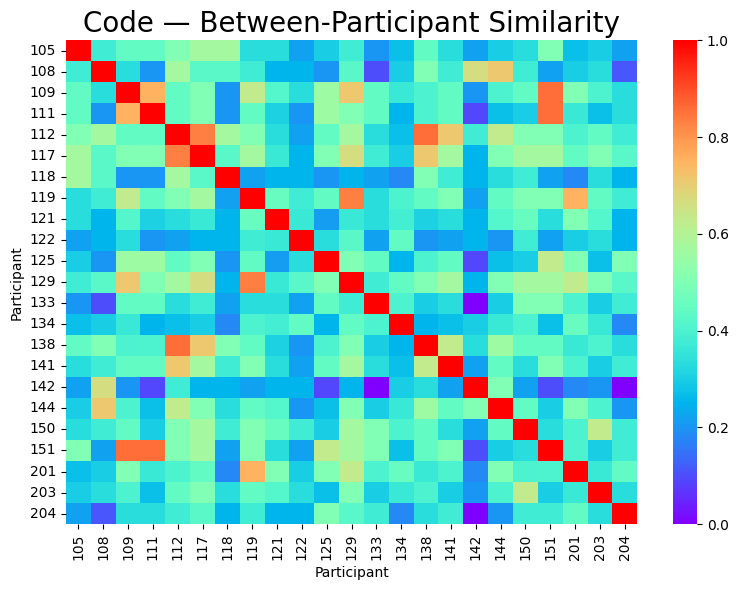

Prose ($\mu = 0.414$, $\sigma = 0.137$)


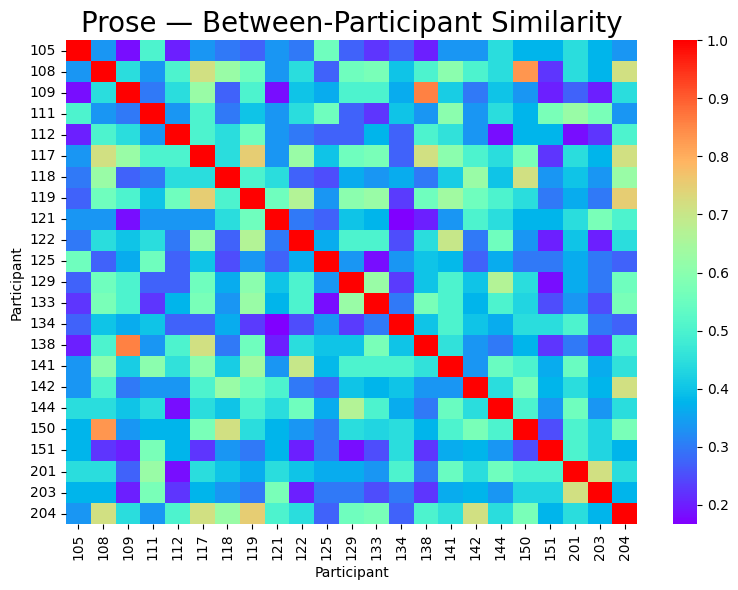

In [55]:
code_jaccard, code_lower, code_mean, code_std  = create_jaccard_matrix('code', sort_by='none')
prose_jaccard, prose_lower, prose_mean, prose_std = create_jaccard_matrix('prose', sort_by='none')

In [56]:
rows,cols = np.tril_indices(code_jaccard.shape[0], k=-1)
code_vals = code_jaccard.values[rows, cols]
prose_vals = prose_jaccard.values[rows,cols]

t,p = stats.ttest_rel(code_vals, prose_vals)
print(f"($t={t:.3f}$, $p={p:.3f}$)", p)

($t=-2.109$, $p=0.036$) 0.03594195718301638


In [57]:
def format_latex_list(regions):
    items = '\n'.join(f'  \\item {r}' for r in regions)
    return (                                                                                                                                                                                                                                                                                                                                                    
        '\\begin{enumerate}[noitemsep, topsep=0pt, parsep=0pt, partopsep=0pt, leftmargin=*]\n'
        + items + '\n'                                                                                                                                                                                                                                                                                                                                          
        '\\end{enumerate}'                                                                                                                                                                                                                                                                                                                                      
    )

def get_top_regions(parcel_dict, n_regions=5):
    parcel_dict = dict(sorted(parcel_dict.items(), key= lambda x: x[1], reverse=True))
    return {region : val for i,(region,val) in enumerate(parcel_dict.items()) if i < n_regions}


def between_participant_jaccard(cfg):
    
    def compute_jaccard_similarity_here(task, p1, p2, top_five_regions_here):
        p1_regions = top_five_regions_here[task][p1]
        p2_regions = top_five_regions_here[task][p2]
        intersection = set.intersection(p1_regions, p2_regions)
        union = set.union(p1_regions, p2_regions)
        return len(intersection) / len(union)
        
    
    top_five_regions_here = {
    'code' : {},
    'prose': {}
    }
    for p in participants:
        mask = (
            (records['participant']== p) &
            (records['task']       == cfg['task']) &
            (records['model']      == cfg['model']) &
            (records['ndelays']    == cfg['ndelays']) &
            (records['look_ahead'] == cfg['look_ahead'])
        )
        for (model, task), df in records[mask].groupby(['model', 'task']):
            # explode by layer
            df['top_region_counts'] = df['top_regions'].apply(lambda row: dict(Counter(row)))
            df['top_five_regions'] = df['top_region_counts'].apply(lambda row: get_top_five_regions(row))
            top_five_regions_here[task][p] = set(df['top_five_regions'].explode())

    participants_sorted = sorted(participants)

    n = len(participants_sorted)

    jaccard_matrix = pd.DataFrame(
        np.zeros((n, n)),
        index=participants_sorted,
        columns=participants_sorted
    )

    for p1 in participants_sorted:
        for p2 in participants_sorted:
            jaccard_matrix.loc[p1, p2] = compute_jaccard_similarity_here(task, p1, p2, top_five_regions_here)
    
    rows,cols = np.tril_indices(jaccard_matrix.shape[0], k=-1)
    vals = jaccard_matrix.values[rows, cols]
    return vals



In [58]:
configs = [
    {'task': 'code',  'model': 'deepseek_6b',   'ndelays': 'ndelays_10', 'look_ahead': 'look_ahead_by_0', 'label': 'DeepSeek 6B',  'n_delays_num': 10, 'look_ahead_num': 0},
    {'task': 'code',  'model': 'codegemma_7b',  'ndelays': 'ndelays_10', 'look_ahead': 'look_ahead_by_1', 'label': 'CodeGemma 7B', 'n_delays_num': 10, 'look_ahead_num': 1},
    {'task': 'code',  'model': 'starcoder2_3b', 'ndelays': 'ndelays_10', 'look_ahead': 'look_ahead_by_0', 'label': 'StarCoder 3B', 'n_delays_num': 10, 'look_ahead_num': 0},
    {'task': 'prose', 'model': 'starcoder2_7b', 'ndelays': 'ndelays_16', 'look_ahead': 'look_ahead_by_3', 'label': 'StarCoder 7B', 'n_delays_num': 16, 'look_ahead_num': 3},
    {'task': 'prose', 'model': 'codegemma_7b',  'ndelays': 'ndelays_16', 'look_ahead': 'look_ahead_by_3', 'label': 'CodeGemma 7B', 'n_delays_num': 16, 'look_ahead_num': 3},
    {'task': 'prose', 'model': 'deepseek_6b',   'ndelays': 'ndelays_16', 'look_ahead': 'look_ahead_by_3', 'label': 'DeepSeek 6B',  'n_delays_num': 16, 'look_ahead_num': 3},
]

results = []

for cfg in configs:
    mask = (
        (records['task']       == cfg['task']) &
        (records['model']      == cfg['model']) &
        (records['ndelays']    == cfg['ndelays']) &
        (records['look_ahead'] == cfg['look_ahead'])
    )
    filtered = records[mask]

    within_jaccards      = []
    participant_region_sets = []
    region_counter       = Counter()

    for (model, task, participant), df in filtered.groupby(['model', 'task', 'participant']):
        if participant in ['101', '130']:
            continue

        df = df.copy()
        # df['top_HarvOx_regions'] = df['top_HarvOx_regions'].apply(lambda row: convert_HarvOx_counts_to_proportions(row))
        df['top_region_counts'] = df['top_regions'].apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_region_counts'].apply(lambda row: get_top_regions(row, n_regions=5))
        df = df.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))

        # Within-participant Jaccard: overlap of top regions across layers
        within_jaccards.append(compute_jaccard(df))

        # Each participant's aggregate top regions (union of per-layer top-5)
        participant_top = set()
        for regions in df['top_five_regions']:
            participant_top.update(regions.keys())
        participant_region_sets.append(participant_top)

        for region in participant_top:
            region_counter[region] += 1

    # Between-participant Jaccard: overlap across participants' aggregate region sets
    if len(participant_region_sets) >= 2:
        # between_j = len(set.intersection(*participant_region_sets)) / len(set.union(*participant_region_sets))
        between_j = between_participant_jaccard(cfg)
    else:
        between_j = float('nan')

    top_10 = [region for region, _ in region_counter.most_common(5)]

    results.append({
        'task':           cfg['task'].capitalize(),
        'model':          cfg['label'],
        'n_delays':       cfg['n_delays_num'],
        'look_ahead':     cfg['look_ahead_num'],
        'avg_within':     np.mean(within_jaccards),
        'std_within':     np.std(within_jaccards),
        'avg_between':    np.nanmean(between_j),
        'std_between':    np.nanstd(between_j),
        'top_10_regions': top_10,
        'n_participants': len(within_jaccards),
    })

    print(f"{cfg['task'].capitalize()} & "
          f"{cfg['label']} & "
          f"{cfg['n_delays_num']} & "
          f"{cfg['look_ahead_num']} & "
          f"{np.mean(within_jaccards):.3f}\\pm{np.std(within_jaccards):.3f} & "
          f"{np.nanmean(between_j):.3f}\\pm{np.nanstd(between_j):.3f} & "
          f"{format_latex_list(top_10)}\\\\\\midrule")

Code & DeepSeek 6B & 10 & 0 & 0.661\pm0.263 & 0.388\pm0.149 & \begin{enumerate}[noitemsep, topsep=0pt, parsep=0pt, partopsep=0pt, leftmargin=*]
  \item Right Frontal Pole
  \item Left Frontal Pole
  \item Right Lateral Occipital Cortex, superior division
  \item Left Lateral Occipital Cortex, superior division
  \item Right Precentral Gyrus
\end{enumerate}\\\midrule
Code & CodeGemma 7B & 10 & 1 & 0.381\pm0.246 & 0.389\pm0.140 & \begin{enumerate}[noitemsep, topsep=0pt, parsep=0pt, partopsep=0pt, leftmargin=*]
  \item Right Frontal Pole
  \item Left Frontal Pole
  \item Right Lateral Occipital Cortex, superior division
  \item Left Lateral Occipital Cortex, superior division
  \item Left Precentral Gyrus
\end{enumerate}\\\midrule
Code & StarCoder 3B & 10 & 0 & 0.552\pm0.235 & 0.422\pm0.148 & \begin{enumerate}[noitemsep, topsep=0pt, parsep=0pt, partopsep=0pt, leftmargin=*]
  \item Right Frontal Pole
  \item Left Frontal Pole
  \item Left Lateral Occipital Cortex, superior division
  \item

In [59]:
results_df = pd.DataFrame.from_dict(results)

In [60]:
t,p = stats.ttest_rel(results_df['avg_within'], results_df['avg_between'])
diff = results_df['avg_within'] - results_df['avg_between']
cohens_d = diff.mean() / diff.std()
print(f"($t={t:.3f}$, $p={p:.3f}$, $d={cohens_d:.3f}$)")
print(f"Within Average: ($\\mu={results_df['avg_within'].mean():.3f}$, $\\sigma={results_df['avg_within'].std():.3f}$) Between Average: ($\\mu={results_df['avg_between'].mean():.3f}$, $\\sigma={results_df['avg_between'].std():.3f}$)")

($t=3.188$, $p=0.024$, $d=1.301$)
Within Average: ($\mu=0.543$, $\sigma=0.108$) Between Average: ($\mu=0.397$, $\sigma=0.017$)
